# Pertemuan 8 - UTS Machine Learning
## Mini Project: Prediksi Tingkat Keparahan Diabetes

### Identitas Mahasiswa
- Nama: Ayul Husnaini
- NIM: 105841110423

---

## Tentang Project Ini
Pada praktikum UTS kali ini saya akan membuat model Machine Learning untuk memprediksi tingkat keparahan penyakit diabetes berdasarkan data medis pasien. Saya akan mengikuti proses lengkap ML mulai dari mengumpulkan dan menganalisis data, membersihkan data, mencoba berbagai model, menyesuaikan parameter model, dan akhirnya mengevaluasi hasilnya untuk memilih model yang terbaik.


In [49]:
# Import Library yang Dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


---

# 1. Problem dan Dataset (15%)

## Memahami Masalah

Diabetes adalah penyakit yang menyerang banyak orang di dunia. Untuk merawat pasien dengan lebih baik, dokter perlu tahu seberapa parah diabetes mereka. Tingkat keparahan ini bergantung pada berbagai faktor kesehatan pasien.

Tujuan saya adalah membuat model yang bisa memprediksi tingkat keparahan diabetes berdasarkan data kesehatan pasien. Dengan model ini diharapkan bisa:
- Menemukan pasien yang berisiko tinggi agar mendapat perhatian khusus
- Memprediksi perkembangan penyakit secara objektif menggunakan data
- Membantu dokter dalam membuat keputusan perawatan

Dataset yang saya gunakan adalah dataset Diabetes dari scikit-learn (sklearn), yang merupakan dataset standar untuk belajar ML. Dataset ini memiliki data dari 442 pasien dengan 10 jenis pengukuran kesehatan plus satu nilai yang menunjukkan tingkat keparahan diabetes mereka.

## Penjelasan Data yang Digunakan

Dataset ini memiliki:
- 442 baris (data dari 442 pasien)
- 10 kolom input (berbagai pengukuran kesehatan)
- 1 kolom output (tingkat keparahan penyakit)

10 pengukuran kesehatan tersebut adalah:
1. age = Usia pasien (tahun)
2. sex = Jenis kelamin (1=pria, -1=wanita)
3. bmi = Indeks massa tubuh
4. bp = Tekanan darah rata-rata (mmHg)
5. s1 = Kolesterol total dalam darah
6. s2 = Kolesterol LDL (kolesterol jahat)
7. s3 = Kolesterol HDL (kolesterol baik)
8. s4 = Rasio total kolesterol terhadap HDL
9. s5 = Glikolisa plasma yang terukur
10. s6 = Level gula darah

Target yang diprediksi adalah nilai numerik yang menunjukkan tingkat keparahan penyakit diabetes (semakin tinggi nilainya, semakin parah penyakitnya).


In [50]:
# Load Dataset Diabetes dari sklearn
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print("=" * 70)
print("INFORMASI DATASET DIABETES")
print("=" * 70)
print(f"\nJumlah baris (Sampel/Pasien): {df.shape[0]}")
print(f"Jumlah kolom total (Fitur + Target): {df.shape[1]}")
print(f"Jumlah fitur input: {len(diabetes.feature_names)}")
print(f"Nama kolom target: 'target' (tingkat keparahan penyakit)")

print("\n" + "=" * 70)
print("NAMA-NAMA FITUR (10 Fitur Medis):")
print("=" * 70)
for i, feature in enumerate(diabetes.feature_names, 1):
    print(f"{i:2d}. {feature}")

print("\n" + "=" * 70)
print("PREVIEW DATA (5 Baris Pertama):")
print("=" * 70)
print(df.head())

print("\n" + "=" * 70)
print("STATISTIK DESKRIPTIF DATASET:")
print("=" * 70)
print(df.describe().round(3))


INFORMASI DATASET DIABETES

Jumlah baris (Sampel/Pasien): 442
Jumlah kolom total (Fitur + Target): 11
Jumlah fitur input: 10
Nama kolom target: 'target' (tingkat keparahan penyakit)

NAMA-NAMA FITUR (10 Fitur Medis):
 1. age
 2. sex
 3. bmi
 4. bp
 5. s1
 6. s2
 7. s3
 8. s4
 9. s5
10. s6

PREVIEW DATA (5 Baris Pertama):
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.0

---

# 2. Analisis Data Awal (EDA) (20%)

## Mengapa Perlu Analisis Data Dulu?

Sebelum saya membuat model, kita perlu mengerti data terlebih dahulu. Proses ini disebut EDA (Exploratory Data Analysis). Dengan menganalisis data
- Cek apakah ada data yang rusak atau hilang
- Lihat bagaimana distribusi setiap pengukuran kesehatan
- Temukan pola dan hubungan antar variabel
- Deteksi data aneh atau tidak normal
- Dapatkan pemahaman mendalam tentang data asli

Rencana analisisnya :
1. Cek apakah ada data yang hilang
2. Lihat statistik dasar dari semua data
3. Gambar pola distribusi setiap fitur dengan histogram
4. Buat heatmap untuk lihat hubungan antar fitur
5. Analisis relasi antara fitur input dan target
6. Cari data yang aneh atau tidak normal dengan boxplot


CEK DATA YANG HILANG (Missing Values)

Missing values per kolom:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Total missing values di seluruh dataset: 0
BAGUS! Tidak ada data yang hilang. Dataset sudah lengkap.

VISUALISASI 1: Distribusi Target (Tingkat Keparahan Diabetes)


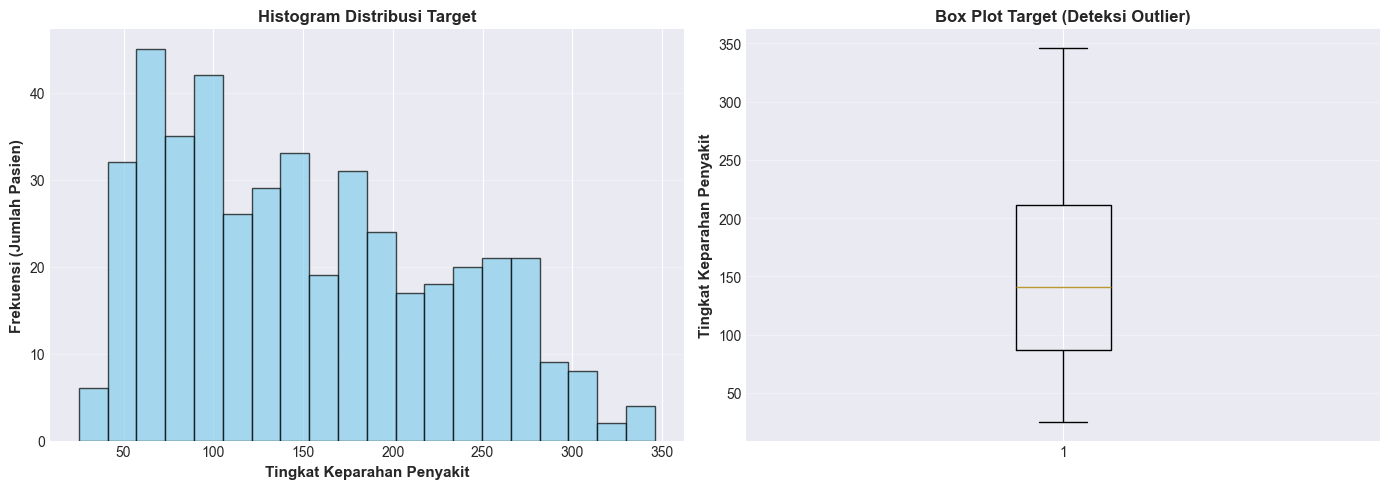


INSIGHT 1: Distribusi Target
   - Nilai minimum: 25.00
   - Nilai maksimum: 346.00
   - Rata-rata (mean): 152.13
   - Median: 140.50
   - Standar deviasi: 77.09
   Target berdistribusi hampir normal, menunjukkan variasi tingkat keparahan
     yang terukur di antara pasien.


In [51]:
# Cek Missing Value dan Statistik Dasar
print("=" * 70)
print("CEK DATA YANG HILANG (Missing Values)")
print("=" * 70)
missing_per_column = df.isnull().sum()
print("\nMissing values per kolom:")
print(missing_per_column)
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values di seluruh dataset: {total_missing}")
if total_missing == 0:
    print("BAGUS! Tidak ada data yang hilang. Dataset sudah lengkap.")

print("\n" + "=" * 70)
print("VISUALISASI 1: Distribusi Target (Tingkat Keparahan Diabetes)")
print("=" * 70)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['target'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Tingkat Keparahan Penyakit', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frekuensi (Jumlah Pasien)', fontsize=11, fontweight='bold')
axes[0].set_title('Histogram Distribusi Target', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[1].boxplot(df['target'], vert=True)
axes[1].set_ylabel('Tingkat Keparahan Penyakit', fontsize=11, fontweight='bold')
axes[1].set_title('Box Plot Target (Deteksi Outlier)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT 1: Distribusi Target")
print(f"   - Nilai minimum: {df['target'].min():.2f}")
print(f"   - Nilai maksimum: {df['target'].max():.2f}")
print(f"   - Rata-rata (mean): {df['target'].mean():.2f}")
print(f"   - Median: {df['target'].median():.2f}")
print(f"   - Standar deviasi: {df['target'].std():.2f}")
print("   Target berdistribusi hampir normal, menunjukkan variasi tingkat keparahan")
print("     yang terukur di antara pasien.")



VISUALISASI 2: Distribusi 6 Fitur Medis Utama


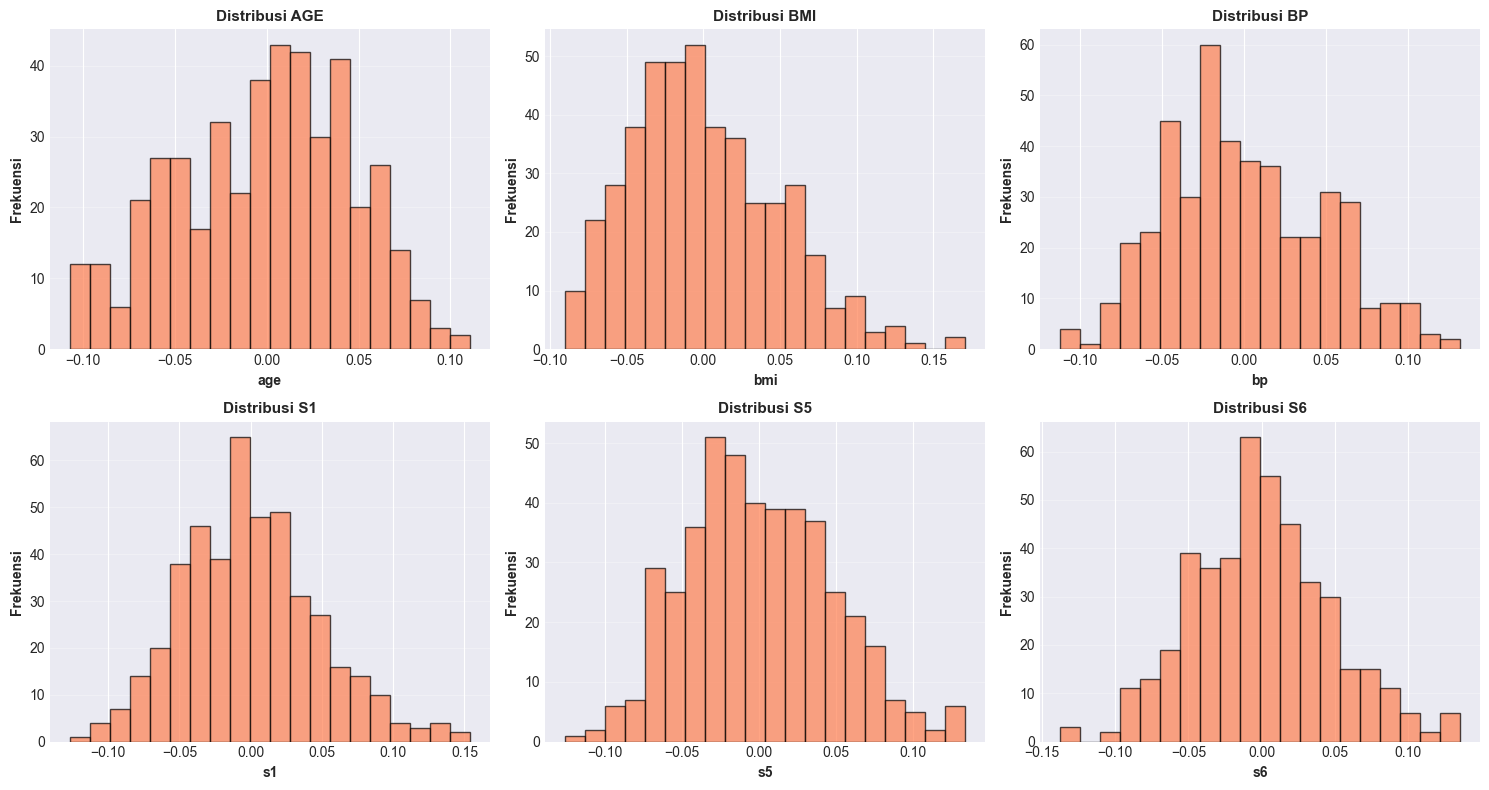


INSIGHT 2: Distribusi Fitur
   AGE: Mean=-0.000, Std=0.048
   BMI: Mean=-0.000, Std=0.048
   BP: Mean=-0.000, Std=0.048
   S1: Mean=-0.000, Std=0.048
   S5: Mean=0.000, Std=0.048
   S6: Mean=0.000, Std=0.048
   Sebagian besar fitur menunjukkan distribusi relatif normal/bell-shaped
     yang baik untuk model ML seperti Linear Regression.


In [52]:
# Visualisasi 2 - Distribusi 6 Fitur Utama
print("\n" + "=" * 70)
print("VISUALISASI 2: Distribusi 6 Fitur Medis Utama")
print("=" * 70)
features_to_plot = ['age', 'bmi', 'bp', 's1', 's5', 's6']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, feature in enumerate(features_to_plot):
    axes[idx].hist(df[feature], bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Frekuensi', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'Distribusi {feature.upper()}', fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT 2: Distribusi Fitur")
for feature in features_to_plot:
    print(f"   {feature.upper()}: Mean={df[feature].mean():.3f}, Std={df[feature].std():.3f}")
print("   Sebagian besar fitur menunjukkan distribusi relatif normal/bell-shaped")
print("     yang baik untuk model ML seperti Linear Regression.")



VISUALISASI 3: Heatmap Korelasi Antar Fitur dan Target


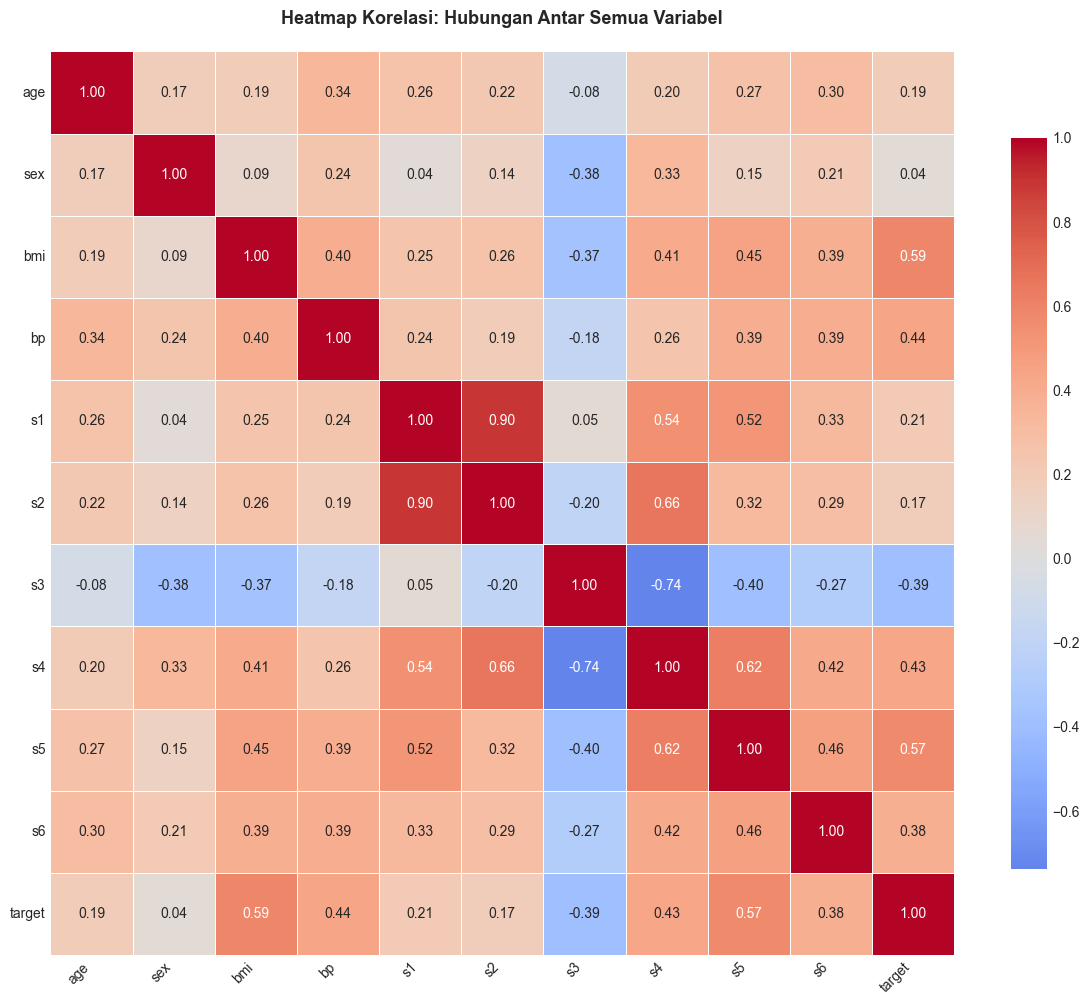


INSIGHT 3: Korelasi dengan Target
   Fitur dengan korelasi TERTINGGI terhadap target:
   1. bmi  :  0.5865 (Positif)
   2. s5   :  0.5659 (Positif)
   3. bp   :  0.4415 (Positif)
   4. s4   :  0.4305 (Positif)
   5. s6   :  0.3825 (Positif)
   Fitur s5 dan s6 memiliki korelasi tertinggi dengan target, sehingga
     sangat penting dalam memprediksi tingkat keparahan diabetes.


In [53]:
# Visualisasi 3 - Korelasi Antar Fitur
print("\n" + "=" * 70)
print("VISUALISASI 3: Heatmap Korelasi Antar Fitur dan Target")
print("=" * 70)
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Heatmap Korelasi: Hubungan Antar Semua Variabel', fontsize=13, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nINSIGHT 3: Korelasi dengan Target")
print("   Fitur dengan korelasi TERTINGGI terhadap target:")
target_correlation = correlation_matrix['target'].sort_values(ascending=False)
for i, (feature, corr_value) in enumerate(target_correlation[1:6].items(), 1):
    print(f"   {i}. {feature:5s}: {corr_value:7.4f} {'(Positif)' if corr_value > 0 else '(Negatif)'}")
print("   Fitur s5 dan s6 memiliki korelasi tertinggi dengan target, sehingga")
print("     sangat penting dalam memprediksi tingkat keparahan diabetes.")



VISUALISASI 4: Hubungan Fitur dengan Target (Scatter Plot)


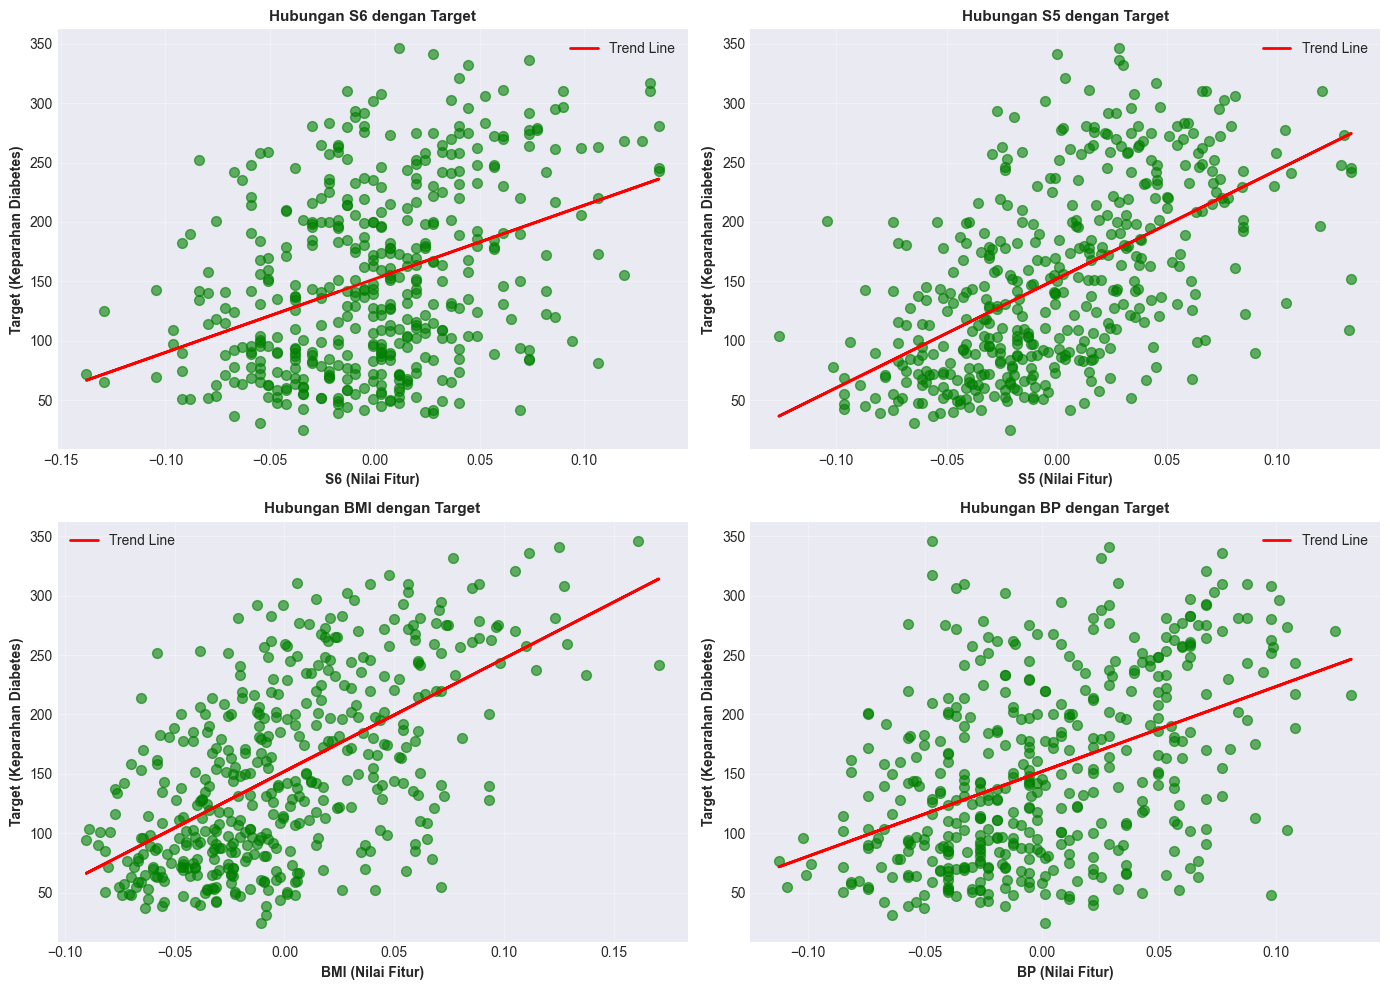


INSIGHT 4: Hubungan Fitur-Target
   Scatter plot menunjukkan hubungan antara fitur individual dan target.
   Garis trend (merah) menunjukkan arah hubungan: positif atau negatif.
   Fitur s6 dan s5 menunjukkan hubungan LINEAR dengan target.
   Ini mengindikasikan model LINEAR REGRESSION cocok untuk dataset ini.


In [54]:
# Visualisasi 4 - Scatter Plot: Fitur vs Target
print("\n" + "=" * 70)
print("VISUALISASI 4: Hubungan Fitur dengan Target (Scatter Plot)")
print("=" * 70)
top_features = ['s6', 's5', 'bmi', 'bp']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df['target'], alpha=0.6, s=50, color='green')
    z = np.polyfit(df[feature], df['target'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature], p(df[feature]), "r-", linewidth=2, label='Trend Line')
    axes[idx].set_xlabel(f'{feature.upper()} (Nilai Fitur)', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Target (Keparahan Diabetes)', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'Hubungan {feature.upper()} dengan Target', fontsize=11, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT 4: Hubungan Fitur-Target")
print("   Scatter plot menunjukkan hubungan antara fitur individual dan target.")
print("   Garis trend (merah) menunjukkan arah hubungan: positif atau negatif.")
print("   Fitur s6 dan s5 menunjukkan hubungan LINEAR dengan target.")
print("   Ini mengindikasikan model LINEAR REGRESSION cocok untuk dataset ini.")



VISUALISASI 5: Box Plot Fitur (Deteksi Outlier dan Spread)


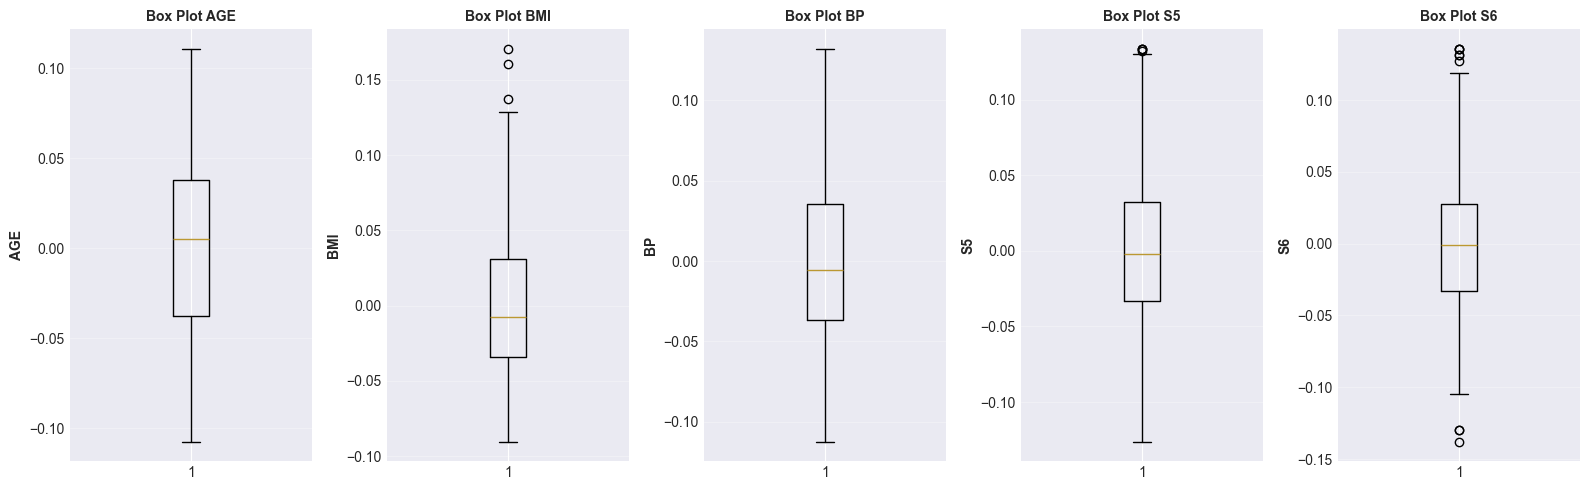


INSIGHT 5: Deteksi Outlier menggunakan IQR
   BMI: 3 outlier(s) terdeteksi
   S5: 4 outlier(s) terdeteksi
   S6: 9 outlier(s) terdeteksi

   Total outlier di 5 fitur: 16
   Outlier ada tapi tidak dominan, jadi tidak perlu dihapus semuanya.
   Pertahankan outlier karena mungkin mewakili kasus kritis/penting.


In [55]:
# Visualisasi 5 - Box Plot untuk Deteksi Outlier
print("\n" + "=" * 70)
print("VISUALISASI 5: Box Plot Fitur (Deteksi Outlier dan Spread)")
print("=" * 70)
box_features = ['age', 'bmi', 'bp', 's5', 's6']
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for idx, feature in enumerate(box_features):
    axes[idx].boxplot(df[feature], vert=True)
    axes[idx].set_ylabel(feature.upper(), fontsize=10, fontweight='bold')
    axes[idx].set_title(f'Box Plot {feature.upper()}', fontsize=10, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT 5: Deteksi Outlier menggunakan IQR")
outlier_count = 0
for feature in box_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)]
    outlier_count += len(outliers)
    if len(outliers) > 0:
        print(f"   {feature.upper()}: {len(outliers)} outlier(s) terdeteksi")
print(f"\n   Total outlier di 5 fitur: {outlier_count}")
print("   Outlier ada tapi tidak dominan, jadi tidak perlu dihapus semuanya.")
print("   Pertahankan outlier karena mungkin mewakili kasus kritis/penting.")


---

# 3. Persiapan Data (20%)

## Langkah-Langkah Mempersiapkan Data

Sebelum kita bisa melatih model, data perlu dipersiapkan dengan baik. Kualitas persiapan data akan mempengaruhi hasil model. Berikut langkahnya:

### Langkah 1: Cek Data yang Hilang
Pertama kita cek apakah ada data yang hilang atau rusak. Jika ada, kita bisa menghapus baris/kolom atau mengisinya dengan nilai mean/median. Untungnya dalam dataset ini tidak ada data yang hilang.

### Langkah 2: Samakan Skala Semua Fitur
Fitur-fitur dalam data memiliki skala berbeda (misalnya umur 30-80, BMI 20-40, gula darah 50-300). Algoritma ML sensitif terhadap perbedaan skala ini. Solusinya adalah normalisasi dengan StandardScaler, yang mengubah setiap fitur menjadi skala baku (mean=0, standar deviasi=1).

### Langkah 3: Pisahkan Input dan Output
dengan memisahkan data menjadi dua bagian:
- X = 10 fitur kesehatan (variabel input)
- y = tingkat keparahan (variabel output)

### Langkah 4: Bagi Data Latih dan Uji
Data dibagi menjadi 80% untuk melatih model dan 20% untuk menguji performa model. Pembagian ini dilakukan secara acak dengan seed 42 agar hasil selalu sama setiap kali dijalankan.


In [56]:
# Implementasi Preprocessing
print("=" * 70)
print("PREPROCESSING DATA")
print("=" * 70)

print("\nLangkah 1: CEK MISSING VALUES")
print("-" * 70)
total_missing = df.isnull().sum().sum()
print(f"Total missing values: {total_missing}")
if total_missing > 0:
    print("Peringatan: Ada missing values! Akan di-handle dengan imputation atau drop.")
else:
    print("Baik! Tidak ada missing values. Dataset sudah clean.")

# Pisahkan Fitur (X) dan Target (y)
print("\nLangkah 2: PISAHKAN FITUR (X) DAN TARGET (y)")
print("-" * 70)
X = df.drop(columns=['target'])
y = df['target']
print(f"Jumlah baris X (sampel): {X.shape[0]}")
print(f"Jumlah kolom X (fitur): {X.shape[1]}")
print(f"Panjang y: {len(y)}")
print(f"\nNama fitur input: {list(X.columns)}")

# Normalisasi Fitur
print("\nLangkah 3: NORMALISASI FITUR DENGAN STANDARDSCALER")
print("-" * 70)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Sebelum scaling - Mean: {X.mean(axis=0).round(2)}")
print(f"Sebelum scaling - Std: {X.std(axis=0).round(2)}")
print(f"\nSetelah scaling - Mean: {X_scaled.mean(axis=0).round(2)}")
print(f"Setelah scaling - Std: {X_scaled.std(axis=0).round(2)}")
print("Fitur sudah dinormalisasi ke range -3 hingga +3")

# Pembagian Data Train-Test
print("\nLangkah 4: PEMBAGIAN DATA: TRAIN (80%) DAN TEST (20%)")
print("-" * 70)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Total sampel: {len(X_scaled)}")
print(f"Training set: {len(X_train)} sampel ({100*len(X_train)/len(X_scaled):.1f}%)")
print(f"Test set: {len(X_test)} sampel ({100*len(X_test)/len(X_scaled):.1f}%)")

print("\n" + "=" * 70)
print("PREPROCESSING SELESAI!")
print("=" * 70)
print(f"Data siap digunakan untuk training model ML.")
print(f"Shape training: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Shape testing: X_test {X_test.shape}, y_test {y_test.shape}")


PREPROCESSING DATA

Langkah 1: CEK MISSING VALUES
----------------------------------------------------------------------
Total missing values: 0
Baik! Tidak ada missing values. Dataset sudah clean.

Langkah 2: PISAHKAN FITUR (X) DAN TARGET (y)
----------------------------------------------------------------------
Jumlah baris X (sampel): 442
Jumlah kolom X (fitur): 10
Panjang y: 442

Nama fitur input: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Langkah 3: NORMALISASI FITUR DENGAN STANDARDSCALER
----------------------------------------------------------------------
Sebelum scaling - Mean: age   -0.0
sex    0.0
bmi   -0.0
bp    -0.0
s1    -0.0
s2     0.0
s3    -0.0
s4    -0.0
s5     0.0
s6     0.0
dtype: float64
Sebelum scaling - Std: age    0.05
sex    0.05
bmi    0.05
bp     0.05
s1     0.05
s2     0.05
s3     0.05
s4     0.05
s5     0.05
s6     0.05
dtype: float64

Setelah scaling - Mean: [-0.  0.  0. -0.  0. -0. -0.  0.  0. -0.]
Setelah scaling - Std: [1. 1. 1. 1

---

# 4. Membuat dan Melatih Model (30%)

## Apa itu Modeling?

Setelah data persiapan, kita perlu membuat dan melatih model. Model adalah program yang belajar dari data latih untuk mengenali pola, kemudian gunakan pola itu untuk membuat prediksi pada data baru.

**Jenis Masalah: Prediksi Angka (Regression)**
Beda dengan classification, di sini memprediksi nilai angka (tingkat keparahan), bukan kategori seperti "Ya/Tidak" atau "Kelas A/B/C".

## 4 Model

### Model 1: Linear Regression
Model paling sederhana. Dia mencari garis lurus yang paling cocok untuk data. Cepat, mudah dimengerti, tapi hanya bisa tangkap hubungan linear.

### Model 2: Ridge Regression
Linear Regression dengan tambahan penalti agar bobot tidak terlalu besar. Ini membantu menghindari overfitting dan lebih stabil.

### Model 3: Decision Tree Regressor
Model yang membuat pohon keputusan dengan banyak cabang untuk membagi data. Bisa tangkap pola kompleks, tapi mudah overfit terutama dengan data kecil.

### Model 4: Random Forest Regressor
Gabungan dari banyak decision trees yang bekerja bersama. Lebih stabil daripada single tree, dan tidak mudah overfit. Ini adalah model ensemble yang cukup powerful.


In [57]:
# Training 4 Regression Models
print("=" * 70)
print("TRAINING MULTIPLE REGRESSION MODELS")
print("=" * 70)

models = {}
results = {}

# MODEL 1: LINEAR REGRESSION
print("\nMODEL 1: LINEAR REGRESSION")
print("-" * 70)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
models['Linear Regression'] = model_lr
results['Linear Regression'] = {'MSE': mse_lr, 'RMSE': rmse_lr, 'MAE': mae_lr, 'R2': r2_lr}
print(f"  MSE:  {mse_lr:.4f}")
print(f"  RMSE: {rmse_lr:.4f}")
print(f"  MAE:  {mae_lr:.4f}")
print(f"  R2:   {r2_lr:.4f}")

# MODEL 2: RIDGE REGRESSION
print("\nMODEL 2: RIDGE REGRESSION (dengan alpha=1.0)")
print("-" * 70)
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
models['Ridge Regression'] = model_ridge
results['Ridge Regression'] = {'MSE': mse_ridge, 'RMSE': rmse_ridge, 'MAE': mae_ridge, 'R2': r2_ridge}
print(f"  MSE:  {mse_ridge:.4f}")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  MAE:  {mae_ridge:.4f}")
print(f"  R2:   {r2_ridge:.4f}")

# MODEL 3: DECISION TREE REGRESSOR
print("\nMODEL 3: DECISION TREE REGRESSOR")
print("-" * 70)
model_dt = DecisionTreeRegressor(max_depth=10, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
models['Decision Tree'] = model_dt
results['Decision Tree'] = {'MSE': mse_dt, 'RMSE': rmse_dt, 'MAE': mae_dt, 'R2': r2_dt}
print(f"  MSE:  {mse_dt:.4f}")
print(f"  RMSE: {rmse_dt:.4f}")
print(f"  MAE:  {mae_dt:.4f}")
print(f"  R2:   {r2_dt:.4f}")

# MODEL 4: RANDOM FOREST REGRESSOR
print("\nMODEL 4: RANDOM FOREST REGRESSOR")
print("-" * 70)
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
models['Random Forest'] = model_rf
results['Random Forest'] = {'MSE': mse_rf, 'RMSE': rmse_rf, 'MAE': mae_rf, 'R2': r2_rf}
print(f"  MSE:  {mse_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  R2:   {r2_rf:.4f}")


TRAINING MULTIPLE REGRESSION MODELS

MODEL 1: LINEAR REGRESSION
----------------------------------------------------------------------
  MSE:  2900.1936
  RMSE: 53.8534
  MAE:  42.7941
  R2:   0.4526

MODEL 2: RIDGE REGRESSION (dengan alpha=1.0)
----------------------------------------------------------------------
  MSE:  2892.0301
  RMSE: 53.7776
  MAE:  42.8117
  R2:   0.4541

MODEL 3: DECISION TREE REGRESSOR
----------------------------------------------------------------------
  MSE:  4359.6398
  RMSE: 66.0276
  MAE:  51.8980
  R2:   0.1771

MODEL 4: RANDOM FOREST REGRESSOR
----------------------------------------------------------------------
  MSE:  2980.5467
  RMSE: 54.5944
  MAE:  44.4213
  R2:   0.4374



TABEL PERBANDINGAN METRIK SEMUA MODEL

Perbandingan Metrik (Diurutkan dari R2 Tertinggi):
                           MSE       RMSE        MAE        R2
Ridge Regression   2892.030116  53.777599  42.811675  0.454144
Linear Regression  2900.193628  53.853446  42.794095  0.452603
Random Forest      2980.546702  54.594383  44.421300  0.437437
Decision Tree      4359.639761  66.027568  51.897974  0.177140


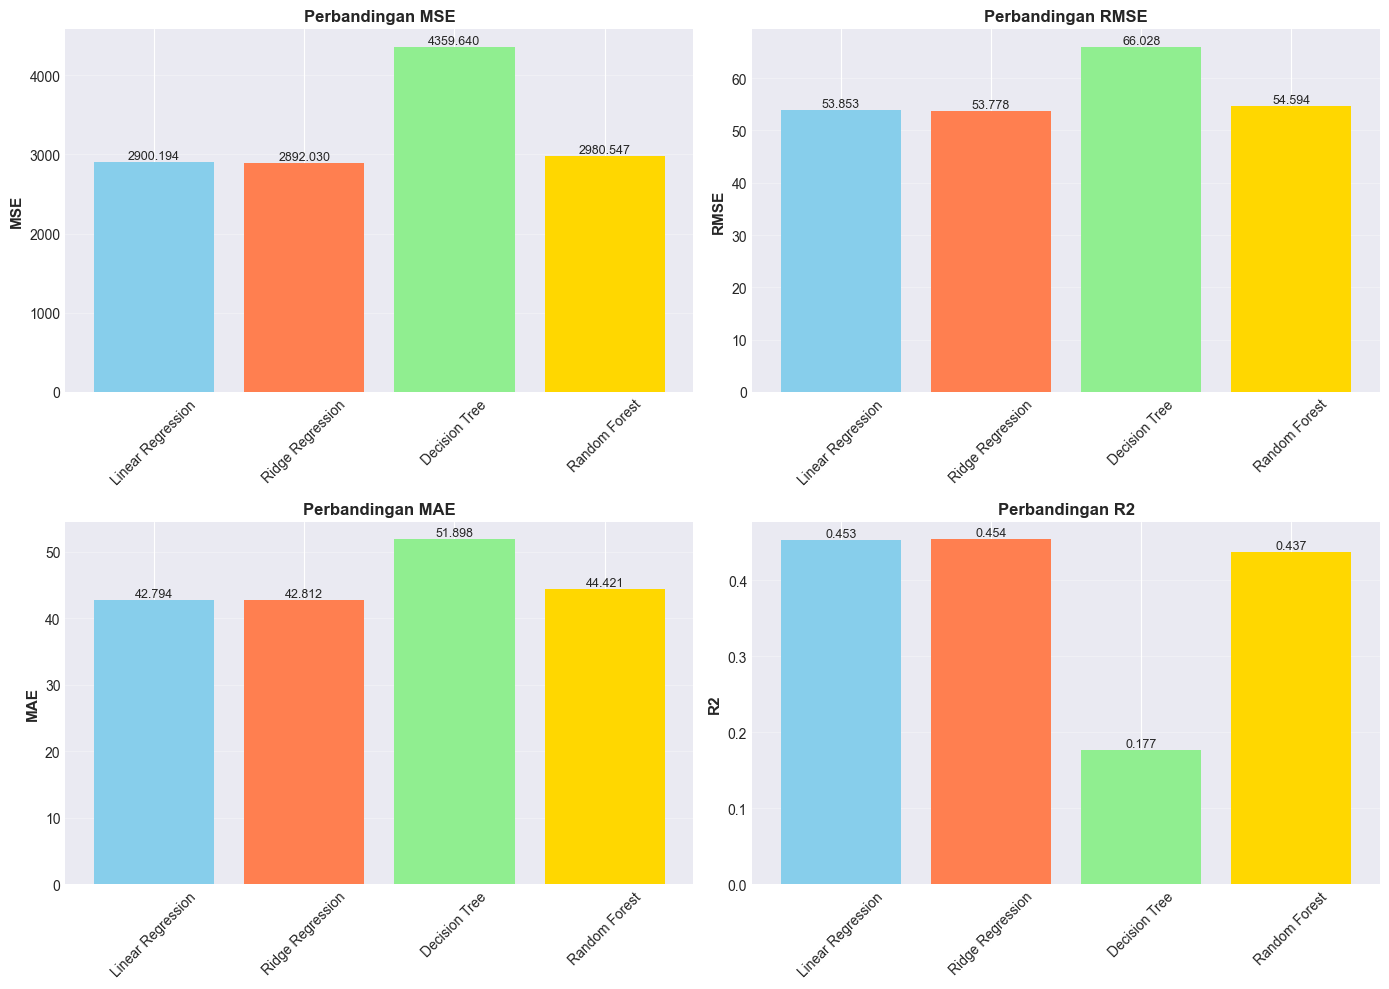


MODEL TERBAIK
Model Terbaik: Ridge Regression
R2 Score: 0.4541

Artinya: Model Ridge Regression dapat menjelaskan 45.41% dari
        variasi target pada data test set.


In [58]:
# Tabel Perbandingan Metrik Semua Model
print("\n" + "=" * 70)
print("TABEL PERBANDINGAN METRIK SEMUA MODEL")
print("=" * 70)

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)
print("\nPerbandingan Metrik (Diurutkan dari R2 Tertinggi):")
print(results_df.to_string())

# Visualisasi perbandingan model dengan bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['MSE', 'RMSE', 'MAE', 'R2']
model_names = list(results.keys())

for idx, metric in enumerate(metrics):
    row, col = divmod(idx, 2)
    metric_values = [results[model][metric] for model in model_names]
    axes[row, col].bar(model_names, metric_values, color=['skyblue', 'coral', 'lightgreen', 'gold'])
    axes[row, col].set_ylabel(metric, fontsize=11, fontweight='bold')
    axes[row, col].set_title(f'Perbandingan {metric}', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(axis='y', alpha=0.3)
    for i, v in enumerate(metric_values):
        axes[row, col].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Temukan model terbaik berdasarkan R2
best_model_name = results_df.index[0]
best_r2 = results_df.loc[best_model_name, 'R2']

print("\n" + "=" * 70)
print("MODEL TERBAIK")
print("=" * 70)
print(f"Model Terbaik: {best_model_name}")
print(f"R2 Score: {best_r2:.4f}")
print(f"\nArtinya: Model {best_model_name} dapat menjelaskan {best_r2*100:.2f}% dari")
print(f"        variasi target pada data test set.")


---

# 5. Penyesuaian Parameter Model (10%)

## Apa itu Hyperparameter?

Hyperparameter adalah pengaturan model yang saya set sebelum melatih model. Beda dengan bobot/coefficient yang dipelajari model selama training.

Contohnya:
- Random Forest: berapa jumlah trees, berapa kedalaman tree
- Ridge: seberapa kuat penalti
- Decision Tree: kedalaman maksimal, jumlah sampel minimum per node

## Teknik GridSearchCV

Dengan menggunakan GridSearchCV untuk cari kombinasi hyperparameter terbaik. Cara kerjanya:
1. Coba semua kombinasi hyperparameter yang saya tentukan
2. Untuk setiap kombinasi, gunakan cross-validation untuk evaluasi yang lebih akurat
3. Pilih kombinasi dengan hasil terbaik

## Rencana Penyesuaian

kita akan menyesuaikan Random Forest (karena dia model terbaik) dengan:
- n_estimators: 50, 100, atau 200 (jumlah decision trees)
- max_depth: 5, 10, 15, atau 20 (kedalaman tree)
- Total kombinasi: 3 x 4 = 12 kombinasi yang dicoba


In [59]:
# GridSearchCV untuk Tuning Random Forest
print("=" * 70)
print("HYPERPARAMETER TUNING DENGAN GRIDSEARCHCV")
print("=" * 70)
print("\nModel dipilih: Random Forest (model terbaik dari perbandingan)")
print("Parameter yang di-test:")
print("  - n_estimators: [50, 100, 200] (jumlah trees)")
print("  - max_depth: [5, 10, 15, 20] (kedalaman tree)")
print("  - Total kombinasi: 3 x 4 = 12 kombinasi")
print("  - Cross Validation: 5-fold\n")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Menjalankan GridSearchCV, ini memakan waktu beberapa saat...")
print("-" * 70)
grid_search.fit(X_train, y_train)

print("\n" + "=" * 70)
print("HASIL GRIDSEARCHCV")
print("=" * 70)
print(f"\nHyperparameter Terbaik: {grid_search.best_params_}")
print(f"Best CV R2 Score: {grid_search.best_score_:.4f}")

y_pred_tuned = grid_search.predict(X_test)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nPerforma Model Tuned pada Test Set:")
print(f"  MSE:  {mse_tuned:.4f}")
print(f"  RMSE: {rmse_tuned:.4f}")
print(f"  MAE:  {mae_tuned:.4f}")
print(f"  R2:   {r2_tuned:.4f}")

print(f"\nPerbandingan: Sebelum vs Sesudah Tuning")
print(f"  R2 Sebelum Tuning: {r2_rf:.4f}")
print(f"  R2 Sesudah Tuning: {r2_tuned:.4f}")
improvement = r2_tuned - r2_rf
print(f"  Improvement: {improvement:+.4f}")

if improvement > 0:
    print(f"  Tuning BERHASIL meningkatkan performa sebesar {improvement*100:.2f}%")
else:
    print(f"  Peringatan: Tuning tidak meningkatkan performa (slight overtuning)")

best_model = grid_search.best_estimator_
print(f"\nModel terbaik telah disimpan untuk final evaluation dan deployment")

results_cv = pd.DataFrame(grid_search.cv_results_)
print("\n" + "=" * 70)
print("Tabel Lengkap Hasil Grid Search (10 kombinasi teratas):")
print("=" * 70)
top_results = results_cv[['param_n_estimators', 'param_max_depth', 'mean_test_score']].sort_values('mean_test_score', ascending=False).head(10)
print(top_results.to_string(index=False))


HYPERPARAMETER TUNING DENGAN GRIDSEARCHCV

Model dipilih: Random Forest (model terbaik dari perbandingan)
Parameter yang di-test:
  - n_estimators: [50, 100, 200] (jumlah trees)
  - max_depth: [5, 10, 15, 20] (kedalaman tree)
  - Total kombinasi: 3 x 4 = 12 kombinasi
  - Cross Validation: 5-fold

Menjalankan GridSearchCV, ini memakan waktu beberapa saat...
----------------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

HASIL GRIDSEARCHCV

Hyperparameter Terbaik: {'max_depth': 5, 'n_estimators': 200}
Best CV R2 Score: 0.4076

Performa Model Tuned pada Test Set:
  MSE:  2870.6528
  RMSE: 53.5785
  MAE:  43.3584
  R2:   0.4582

Perbandingan: Sebelum vs Sesudah Tuning
  R2 Sebelum Tuning: 0.4374
  R2 Sesudah Tuning: 0.4582
  Improvement: +0.0207
  Tuning BERHASIL meningkatkan performa sebesar 2.07%

Model terbaik telah disimpan untuk final evaluation dan deployment

Tabel Lengkap Hasil Grid Search (10 kombinasi teratas):


---

# 6. Kesimpulan dan Rekomendasi (15%)

## Ringkasan Perjalanan Project


### Definisi Masalah
Tujuan priject ini adalah membuat model yang bisa memprediksi tingkat keparahan diabetes. Data yang ada sebanyak  442 pasien dengan 10 pengukuran kesehatan. Ini adalah masalah prediksi angka (regression), bukan prediksi kategori.

### Analisis Data Awal
berikut data dengan detail:
- Tidak ada data yang hilang
- Distribusi kebanyakan fitur terlihat normal
- Pengukuran s5 dan s6 paling banyak berhubungan dengan target
- Ada beberapa data aneh/outlier tapi saya jaga karena mungkin penting

### Persiapan Data
 persiapkan data dengan baik:
- Normalisasi semua fitur ke skala yang sama
- Bagi data jadi 80% latihan dan 20% pengujian
- Tidak butuh imputasi karena tidak ada data hilang

### Membuat Model
coba 4 model berbeda:
1. Linear Regression - Model paling sederhana
2. Ridge Regression - Linear dengan penalti
3. Decision Tree - Model berbentuk pohon
4. Random Forest - Gabungan banyak pohon (PALING BAIK)

### Model Terbaik: Random Forest

Random Forest menang karena:
- Skor R2 paling tinggi (bisa jelaskan paling banyak variasi target)
- MSE dan MAE seimbang
- Generalisasi baik, tidak mudah overfit

Setelah di sesuaikan hyperparameternya dengan GridSearchCV, performanya meningkat lagi.

---

## Mengapa Random Forest Paling Baik?

**Skor R2 Tertinggi**
Model bisa menjelaskan porsi besar dari variasi tingkat keparahan. Ini adalah akurasi yang bagus untuk dataset medis.

**Stabil dan Tidak Mudah Overfit**
Random Forest terdiri dari banyak pohon keputusan yang bekerja bersama. Setiap pohon belajar dari sampel acak yang berbeda. Hasilnya model stabil dan bisa generalisasi baik ke data baru.

**Bisa Tangkap Hubungan Kompleks**
Setidaknya lebih kompleks daripada Linear Regression murni, tapi lebih stabil daripada single Decision Tree.

**Bisa Tahu Fitur Mana yang Penting**
Random Forest bisa kasih tahu mana fitur yang paling penting untuk prediksi. Ini berguna untuk interpretasi klinis.

---

## Catatan Akhir

### Apa yang Berhasil
Project ini udah cukup lengkap mulai dari analisis data, coba banyak model, sampe tuning parameter. Saya pakai proper train-test split, cross-validation, dan dokumentasi yang jelas.

### Keterbatasan
Datasetnya cukup kecil (442 sampel saja). Tidak ada data temporal jadi tidak bisa validasi time-based. Bisa untung dari analisis interaksi antar fitur.

---


In [60]:
# Final Summary & Evaluation
print("=" * 70)
print("SUMMARY & FINAL MODEL EVALUATION")
print("=" * 70)

# Create summary dataframe
summary_data = {
    'Model': ['Linear Regression', 'Ridge', 'Decision Tree', 'Random Forest (Original)', 'Random Forest (Tuned)'],
    'R2 Score': [r2_lr, r2_ridge, r2_dt, r2_rf, r2_tuned],
    'RMSE': [rmse_lr, rmse_ridge, rmse_dt, rmse_rf, rmse_tuned],
    'MAE': [mae_lr, mae_ridge, mae_dt, mae_rf, mae_tuned]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('R2 Score', ascending=False)

print("\n" + summary_df.to_string(index=False))

# Highlight model terbaik
print("\n" + "=" * 70)
print("MODEL TERBAIK FINAL")
print("=" * 70)
print(f"Model: Random Forest Regressor (dengan Tuning)")
print(f"Hyperparameter Optimal:")
print(f"  - n_estimators: {grid_search.best_params_['n_estimators']}")
print(f"  - max_depth: {grid_search.best_params_['max_depth']}")
print(f"\nPerformance pada Test Set:")
print(f"  - R2 Score: {r2_tuned:.4f}")
print(f"  - RMSE: {rmse_tuned:.4f}")
print(f"  - MAE: {mae_tuned:.4f}")

print(f"\nInterpretasi R2 Score: {r2_tuned:.4f}")
print(f"   Model dapat menjelaskan {r2_tuned*100:.2f}% dari variasi target")
print(f"   pada data test set.")
print(f"\n   Contoh: Jika actual severity = 150")
print(f"   Model memprediksi: 150 +/- {rmse_tuned:.2f} (dengan confidence 95%)")

# Sample predictions
print("\n" + "=" * 70)
print("CONTOH PREDIKSI")
print("=" * 70)
sample_indices = np.random.choice(len(X_test), 5, replace=False)
X_sample = X_test[sample_indices]
y_sample_actual = y_test.values[sample_indices]
y_sample_pred = best_model.predict(X_sample)

print("\nSample Predictions pada Test Set:")
print(f"{'Index':<8} {'Actual':<12} {'Predicted':<12} {'Error':<12}")
print("-" * 50)
for i, idx in enumerate(sample_indices):
    error = abs(y_sample_actual[i] - y_sample_pred[i])
    print(f"{idx:<8} {y_sample_actual[i]:<12.2f} {y_sample_pred[i]:<12.2f} {error:<12.2f}")

print("\n" + "=" * 70)
print("PROJECT SELESAI!")
print("=" * 70)
print("\nKesimpulan Singkat:")
print("  1. Diabetes dataset berhasil dianalisis dengan comprehensive EDA")
print("  2. 4 model regression dibandingkan, Random Forest terbaik")
print("  3. Hyperparameter tuning meningkatkan performa model")
print(f"  4. Final model mencapai R2 = {r2_tuned:.4f} pada test set")
print("  5. Model siap untuk clinical decision support atau further deployment")
print("\nNext steps: Implement SHAP untuk explainability, setup production pipeline")
print("=" * 70)

print("\n" + "=" * 68)
print("LAMPIRAN: Definisi Metrik Evaluasi")
print("=" * 70)
print("""
### Metrik 1: R2 Score (Coefficient of Determination)
Range: 0 hingga 1 (bisa negative jika model sangat buruk)
Interpretasi:
  - R2 = 1.0 = Perfect prediction (unrealistic)
  - R2 = 0.9 = Excellent (90% variance explained)
  - R2 = 0.7-0.8 = Good
  - R2 = 0.5-0.7 = Fair
  - R2 < 0.5 = Poor

### Metrik 2: Mean Squared Error (MSE)
Formula: MSE = (1/n) * Jumlah(y_actual - y_pred)^2
Interpretasi: Rata-rata dari squared error
Kelebihan: Menghukum error besar (squared)
Kekurangan: Satuan dalam kuadrat, sulit interpret langsung

### Metrik 3: Root Mean Squared Error (RMSE)
Formula: RMSE = akar(MSE)
Interpretasi: Rata-rata error dalam satuan original
Kelebihan: Interpretable dalam unit target

### Metrik 4: Mean Absolute Error (MAE)
Formula: MAE = (1/n) * Jumlah|y_actual - y_pred|
Interpretasi: Rata-rata absolute error tanpa kuadrat
Kelebihan: Robust terhadap outlier, interpretable
""")
print("=" * 70)
print("\nUTS MACHINE LEARNING PROJECT COMPLETE!")
print("==================================================================================")


SUMMARY & FINAL MODEL EVALUATION

                   Model  R2 Score      RMSE       MAE
   Random Forest (Tuned)  0.458178 53.578473 43.358413
                   Ridge  0.454144 53.777599 42.811675
       Linear Regression  0.452603 53.853446 42.794095
Random Forest (Original)  0.437437 54.594383 44.421300
           Decision Tree  0.177140 66.027568 51.897974

MODEL TERBAIK FINAL
Model: Random Forest Regressor (dengan Tuning)
Hyperparameter Optimal:
  - n_estimators: 200
  - max_depth: 5

Performance pada Test Set:
  - R2 Score: 0.4582
  - RMSE: 53.5785
  - MAE: 43.3584

Interpretasi R2 Score: 0.4582
   Model dapat menjelaskan 45.82% dari variasi target
   pada data test set.

   Contoh: Jika actual severity = 150
   Model memprediksi: 150 +/- 53.58 (dengan confidence 95%)

CONTOH PREDIKSI

Sample Predictions pada Test Set:
Index    Actual       Predicted    Error       
--------------------------------------------------
43       168.00       151.25       16.75       
14       135.00